In [45]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import importlib

In [46]:
from parameters import *
from calculated_params import *
from openEMS.physical_constants import *
workspace_root = os.getcwd()

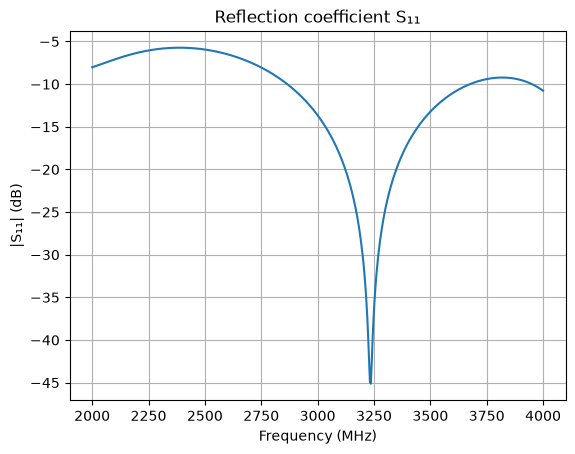

In [47]:
freq = np.linspace(f0 - fc, f0 + fc, 501)
plt.plot(freq/1e6,20 * np.log10(np.abs(s11)))
plt.xlabel('Frequency (MHz)')
plt.ylabel('|S₁₁| (dB)')
plt.title('Reflection coefficient S₁₁')
plt.grid()
plt.show()

In [48]:
h5_path = os.path.join(workspace_root, 'omega_loop', 'HField.h5')
with h5py.File(h5_path, 'r') as f:
    x = f['Mesh/x'][:] / unit             
    y = f['Mesh/y'][:] / unit             
    z = f['Mesh/z'][:] / unit             
    real = f['FieldData/FD/f0_real'][:]   # (3, Nz, Ny, Nx)
    imag = f['FieldData/FD/f0_imag'][:]
    print("\n=== Full structure ===")
    def show(name, obj):
        kind = 'Group' if isinstance(obj, h5py.Group) else 'Dataset'
        extra = f" shape={obj.shape} dtype={obj.dtype}" if kind == 'Dataset' else ""
        print(f"{kind}: {name}{extra}")
        if hasattr(obj, 'attrs') and len(obj.attrs):
            print(f"    attrs: {dict(obj.attrs)}")
    f.visititems(show)


=== Full structure ===
Group: FieldData
Group: FieldData/FD
    attrs: {'frequency': array([2.87e+09])}
Dataset: FieldData/FD/f0_imag shape=(3, 5, 83, 82) dtype=float32
    attrs: {'frequency': array([2.87e+09], dtype=float32)}
Dataset: FieldData/FD/f0_real shape=(3, 5, 83, 82) dtype=float32
    attrs: {'frequency': array([2.87e+09], dtype=float32)}
Group: Mesh
Dataset: Mesh/x shape=(82,) dtype=float32
Dataset: Mesh/y shape=(83,) dtype=float32
Dataset: Mesh/z shape=(5,) dtype=float32


In [49]:
z

array([-0.187875,  0.15    ,  0.48    ,  0.829   ,  1.2177  ],
      dtype=float32)

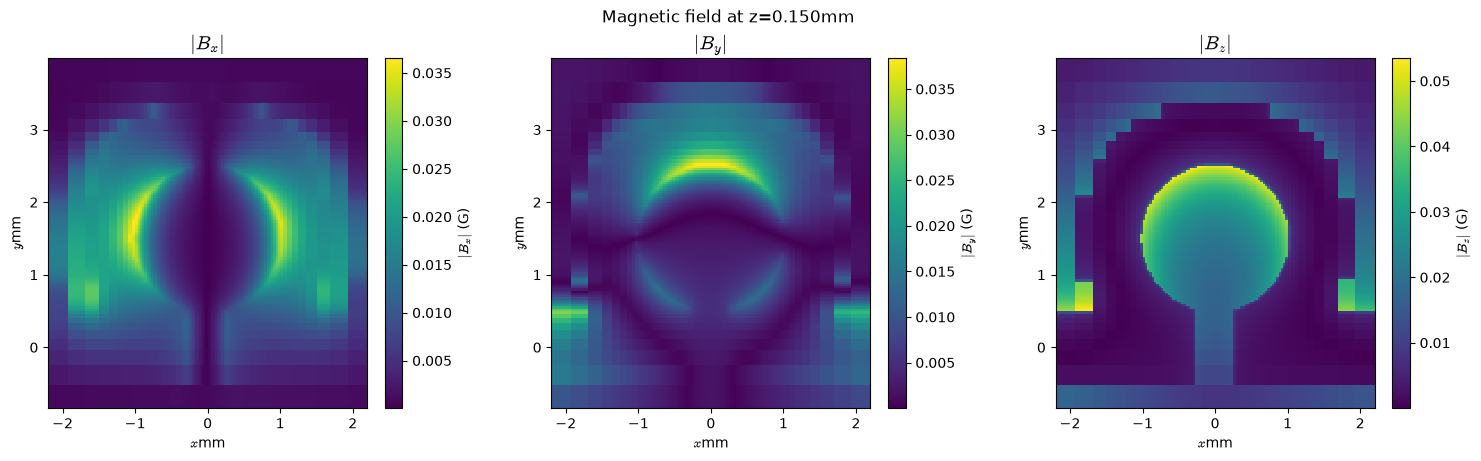

In [50]:
plane_of_analysis=1
Power=1e-3
H_all = real + 1j * imag
B_all = MUE0 * H_all*1e4*np.sqrt(Power) /np.sqrt(P0_in)
X, Y = np.meshgrid(x, y, indexing='xy')
Bx_MW = B_all[0, plane_of_analysis, :, :]
By_MW = B_all[1, plane_of_analysis, :, :]
Bz_MW = B_all[2, plane_of_analysis, :, :]

Bx_mag = np.abs(Bx_MW)
By_mag = np.abs(By_MW)
Bz_mag = np.abs(Bz_MW)

plt.rcParams.update({"mathtext.fontset": "cm"})
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
components = [(Bx_mag, r'$|B_x|$'), (By_mag, r'$|B_y|$'), (Bz_mag, r'$|B_z|$')]
for ax, (Bc, title) in zip(axes, components):
    pcm = ax.pcolormesh(X, Y, Bc, cmap='viridis', shading='auto')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(r'$x$mm')
    ax.set_ylabel(r'$y$mm')
    ax.set_aspect('equal')
    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label(title + r' (G)')
plt.suptitle(f"Magnetic field at z={z[plane_of_analysis]:.3f}mm")
plt.show()

In [51]:
def get_rotation_matrix_lab(idx_nv):
    """ Returns the transformation matrix from lab frame to the desired 
    NV frame, identified by idx_nv (can be 1, 2, 3 or 4) """
    if idx_nv == 1:
        RNV = np.array([[0, 1, 0], 
                        [-np.sqrt(1 / 3), 0,np.sqrt(2 / 3)],
                        [np.sqrt(2 / 3), 0, np.sqrt(1 / 3)]])
    elif idx_nv == 2:
        RNV = np.array([[1, 0, 0], 
                        [0, np.sqrt(1 / 3), -np.sqrt(2 / 3)],
                        [0, -np.sqrt(2 / 3), -np.sqrt(1 / 3)]])
    elif idx_nv == 3:
        RNV = np.array([[1, 0, 0], 
                        [0, -np.sqrt(1 / 3), -np.sqrt(2 / 3)],
                        [0, np.sqrt(2 / 3), -np.sqrt(1 / 3)]])
    elif idx_nv == 4:
        RNV = np.array([[0, 1, 0],
                        [np.sqrt(1 / 3),0,np.sqrt(2 / 3)],
                        [-np.sqrt(2 / 3),0,np.sqrt(1 / 3)]])
    return RNV
def get_rotation_matrix_lat(idx_nv):
    """Returns the transformation matrix from lab frame to the desired
    NV frame, identified by idx_nv (1, 2, 3 or 4)."""
    if idx_nv == 1:      
        RNV = np.array([[ 1/np.sqrt(2), -1/np.sqrt(2),  0],
                        [ 1/np.sqrt(6),  1/np.sqrt(6), -2/np.sqrt(6)],
                        [ 1/np.sqrt(3),  1/np.sqrt(3),  1/np.sqrt(3)]])
    elif idx_nv == 2:    
        RNV = np.array([[ 1/np.sqrt(2),  1/np.sqrt(2),  0],
                        [ 1/np.sqrt(6), -1/np.sqrt(6),  2/np.sqrt(6)],
                        [ 1/np.sqrt(3), -1/np.sqrt(3), -1/np.sqrt(3)]])
    elif idx_nv == 3:
        RNV = np.array([[-1/np.sqrt(2), -1/np.sqrt(2),  0],
                        [-1/np.sqrt(6),  1/np.sqrt(6),  2/np.sqrt(6)],
                        [-1/np.sqrt(3),  1/np.sqrt(3), -1/np.sqrt(3)]])
    elif idx_nv == 4:
        RNV = np.array([[-1/np.sqrt(2),  1/np.sqrt(2),  0],
                        [-1/np.sqrt(6), -1/np.sqrt(6), -2/np.sqrt(6)],
                        [-1/np.sqrt(3), -1/np.sqrt(3),  1/np.sqrt(3)]])
    return RNV

In [52]:
import qutip as qu
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
orange_cmap = LinearSegmentedColormap.from_list("white_orange_black", ["black", "orange", "white"])

# Static magnetic field (T)
Bx = 0.0
By = 0.0
Bz = 0.0

gamma=2*np.pi*28*1e9    #rad s-1
D=2*np.pi*2.87*1e9      #rad s-1 T-1

In [53]:
Sx = qu.jmat(1, 'x')
Sy = qu.jmat(1, 'y')
Sz = qu.jmat(1, 'z')

In [54]:
H0 = D * (Sz**2) + gamma * (Bx*Sx + By*Sy + Bz*Sz)

In [55]:
eigenvalues, eigenstates = H0.eigenstates()
print(eigenvalues,eigenstates)

[0.00000000e+00 1.80327418e+10 1.80327418e+10] [Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
 Qobj data =
 [[0.]
  [1.]
  [0.]]
 Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
 Qobj data =
 [[1.]
  [0.]
  [0.]]
 Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
 Qobj data =
 [[0.]
  [0.]
  [1.]]                                                                ]


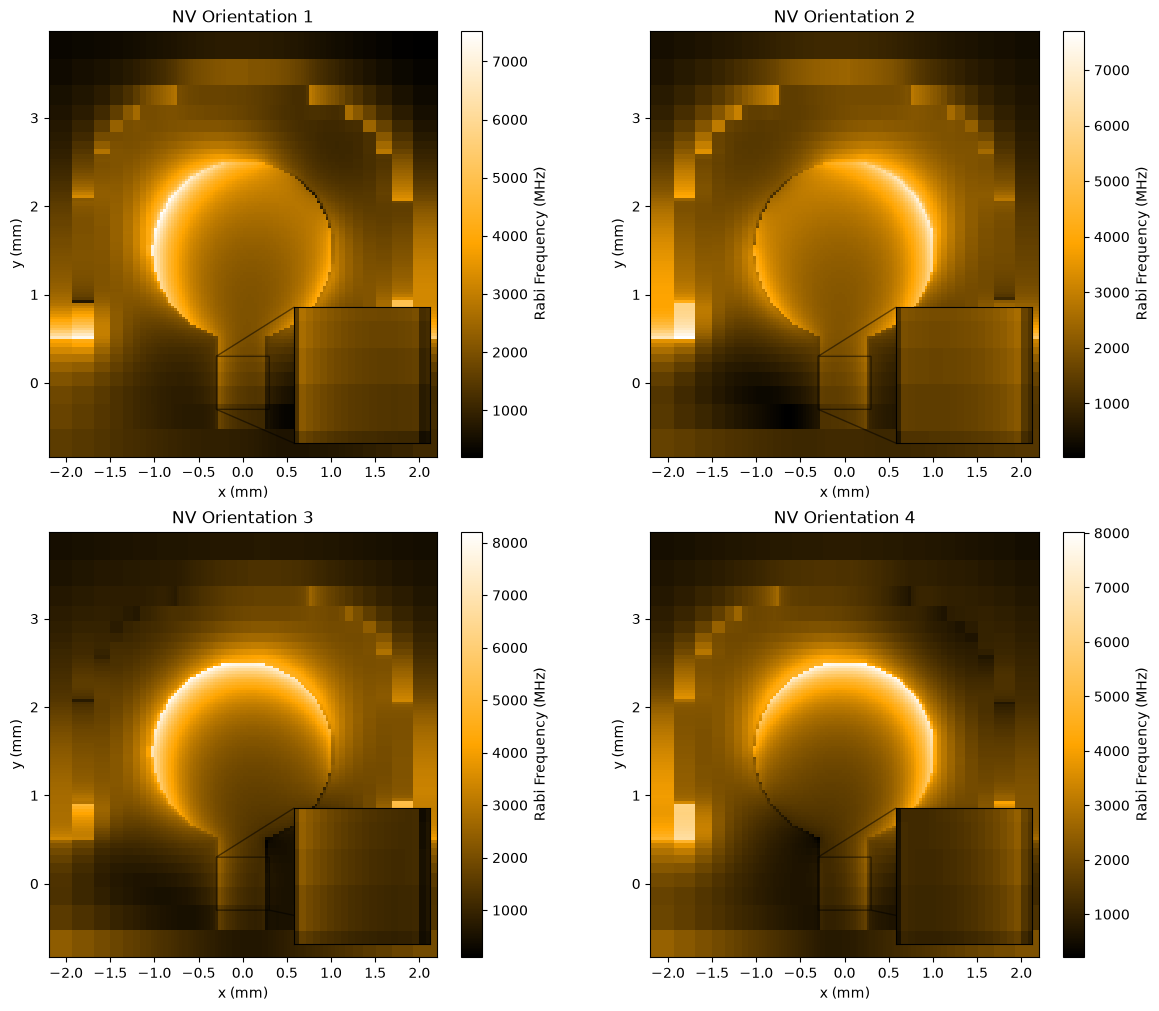

In [ ]:
B = np.stack((Bx_MW, By_MW, Bz_MW))

phase_x = 0
phase_y = 0
phase_z = 0
g, d, b = eigenstates
Eg, Ed, Eb = eigenvalues

fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
for idx_nv, ax in zip([1, 2, 3, 4], axes.ravel()):
    RM = get_rotation_matrix_lat(idx_nv)
    B_rot = np.einsum('ij,jkl->ikl', RM, B)
    Bx = B_rot[0]
    By = B_rot[1]
    Bz = B_rot[2]
    Ny, Nx = Bx.shape
    R = np.zeros((Ny, Nx))
    for iy in range(Ny):
        for ix in range(Nx):
            Hmw = gamma * (Bx[iy, ix] * np.exp(1j * phase_x) * Sx +
                           By[iy, ix] * np.exp(1j * phase_y) * Sy +
                           Bz[iy, ix] * np.exp(1j * phase_z) * Sz)
            R[iy, ix] = np.abs(g.dag() * Hmw * d)
    pcm = ax.pcolormesh(x,y,R/1e6,shading="auto",cmap=orange_cmap)
    ax.set_title(f"NV Orientation {idx_nv}")
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.set_aspect("equal")
    fig.colorbar(pcm,ax=ax,label="Rabi Frequency (MHz)")
    axins = inset_axes(ax, width="35%", height="35%", loc="lower right")
    x1, x2 = -0.3, 0.3
    y1, y2 = -0.3, 0.3
    pcm2 = axins.pcolormesh(x,y,R/1e6,shading="auto",cmap=orange_cmap)
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)
    axins.set_xticks([])
    axins.set_yticks([])
    axins.set_aspect("equal")
    ax.indicate_inset_zoom(axins, edgecolor="black")
plt.show()